# Principal Component Analysis — From Theory to Production
## Breast Cancer Diagnostics Case Study

**Objective:** Diagnose severe multicollinearity in 30 clinical features, apply PCA from scratch,  
validate against sklearn, and quantify the accuracy-vs-efficiency trade-off in a classification pipeline.

**Dataset:** Wisconsin Breast Cancer (569 samples × 30 features → binary: Benign / Malignant)

---
### Pipeline Overview
```
Raw Data → Correlation Clustering → VIF Analysis → PCA (SVD & Eigen) → Validation → Classification
```

In [1]:
import time
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             f1_score, recall_score)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Global plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'font.size'       : 11,
})
RANDOM_STATE = 42

## 1. Data Loading & Preprocessing

Minimal cleaning: drop the ID column and artifact column (`Unnamed: 32`), encode the binary label.  
No scaling here — correlation is scale-invariant and will be computed on raw features.

In [6]:
df = pd.read_csv('breast_cancer_dataset.csv')
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X_raw = df.drop('diagnosis', axis=1)
y     = df['diagnosis']

# ── Basic sanity checks ───────────────────────────────────────────────────────
print(f"Shape        : {X_raw.shape}")
print(f"Missing      : {X_raw.isnull().sum().sum()}")
print(f"Class balance: {y.value_counts()[0]} Benign ({y.value_counts()[0]/len(y)*100:.1f}%)"
      f" | {y.value_counts()[1]} Malignant ({y.value_counts()[1]/len(y)*100:.1f}%)")

print(f"\nTop-5 features by skewness (|skew| > 1 = right-skewed, relevant for outlier sensitivity):")
print(X_raw.skew().abs().sort_values(ascending=False).head().round(2).to_string())

print(f"\nOutliers (|z-score| > 3) per feature — top 5:")
from scipy import stats
z_counts = pd.Series(
    (np.abs(stats.zscore(X_raw)) > 3).sum(axis=0),  # sum over rows per feature
    index=X_raw.columns
).sort_values(ascending=False)
print(z_counts.head().to_string())

print("\nNote: PCA (covariance-based) is sensitive to outliers."
      " High skew / outliers noted but not removed —"
      " standard practice on this benchmark dataset.")

Shape        : (569, 30)
Missing      : 0
Class balance: 357 Benign (62.7%) | 212 Malignant (37.3%)

Top-5 features by skewness (|skew| > 1 = right-skewed, relevant for outlier sensitivity):
area_se                 5.45
concavity_se            5.11
fractal_dimension_se    3.92
perimeter_se            3.44
radius_se               3.09

Outliers (|z-score| > 3) per feature — top 5:
compactness_se          12
symmetry_se             11
compactness_worst       10
area_worst              10
fractal_dimension_se    10

Note: PCA (covariance-based) is sensitive to outliers. High skew / outliers noted but not removed — standard practice on this benchmark dataset.


**Dataset:** 569 samples × 30 features, no missing values — no imputation needed.

**Class balance:** 63/37 (Benign/Malignant) — mild imbalance, not severe enough to require
oversampling. Stratified splitting preserves this ratio in train/test sets.

**Skewness:** 5 features have |skew| > 3 (area_se = 5.45, concavity_se = 5.11).
Standardization centers the data but does not correct skewness — heavy tails remain.
PCA is sensitive to variance inflation from skewed distributions, meaning these features
may exert disproportionate influence on principal components.

**Outliers:** compactness_se and symmetry_se each contain ~10–12 z-score outliers (~2% of samples).
At n=569 the covariance distortion is modest and no strong instability was observed in PCA results.
Robust PCA could be considered if outlier influence materially affected downstream components.

**No scaling here** — correlation and VIF are computed on raw features.
Pearson correlation is scale-invariant by definition. Scaling is applied exclusively before PCA.

## 2. Feature Correlation Structure

**Why before PCA?**  
PCA's principal components are determined by variance and correlation.  
Understanding the correlation structure first tells us *how many* meaningful components to expect  
and *which features* will dominate each one.

**Why no scaling here?**  
Pearson correlation divides by σ internally — it is scale-invariant by definition.  
Scaling before correlation is redundant and can obscure natural variance structure.

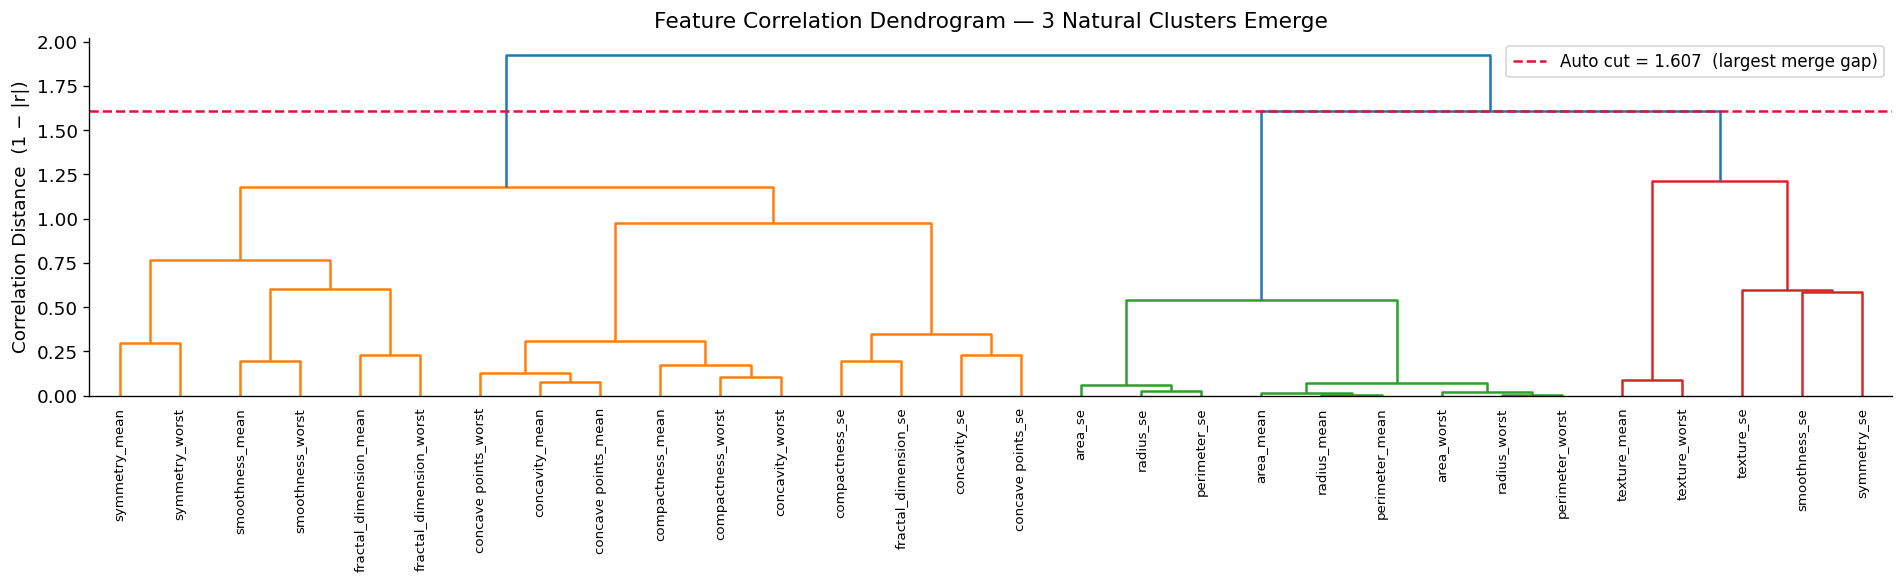

Auto-detected clusters: 3

  Cluster 2 — Size/Geometry (9 features)
    ['radius_mean', 'perimeter_mean', 'area_mean', 'radius_se', 'perimeter_se', 'area_se', 'radius_worst', 'perimeter_worst', 'area_worst']

  Cluster 3 — Texture/Noise (5 features)
    ['texture_mean', 'texture_se', 'smoothness_se', 'symmetry_se', 'texture_worst']

  Cluster 1 — Shape Complexity (16 features)
    ['smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'compactness_se', 'concavity_se', 'concave points_se', 'fractal_dimension_se', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']



In [7]:
# ── Correlation-based distance: 0 = identical, 1 = uncorrelated ─────────────
corr_matrix     = X_raw.corr().abs()
distance_matrix = 1 - corr_matrix
np.fill_diagonal(distance_matrix.values, 0)          # fix float precision noise

# Ward linkage: technically assumes Euclidean distance (known limitation),
# but selected empirically after testing alternatives.
# Average linkage over-fragmented (10 clusters), while complete linkage
# produced less interpretable groupings. Ward yielded the most coherent
# and stable 3-cluster structure, further supported by PCA loadings alignment.
linkage_matrix  = linkage(squareform(distance_matrix), method='ward')

# ── Auto best-cut: largest gap between consecutive merge distances ────────────
# The biggest jump = the algorithm had to travel furthest to merge two groups
# → natural cluster boundary
merge_distances = linkage_matrix[:, 2]
gaps            = np.diff(merge_distances)
best_cut        = merge_distances[np.argmax(gaps) + 1] - 1e-5

# ── Dendrogram ────────────────────────────────────────────────────────────────
plt.figure(figsize=(16, 5))
dendrogram(linkage_matrix, labels=X_raw.columns.tolist(),
           leaf_rotation=90, leaf_font_size=8, color_threshold=best_cut)
plt.axhline(y=best_cut, color='crimson', linestyle='--', linewidth=1.5,
            label=f'Auto cut = {best_cut:.3f}  (largest merge gap)')
plt.title('Feature Correlation Dendrogram — 3 Natural Clusters Emerge', fontsize=13)
plt.ylabel('Correlation Distance  (1 − |r|)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ── Assign cluster labels ─────────────────────────────────────────────────────
labels     = fcluster(linkage_matrix, t=best_cut, criterion='distance')
n_clusters = labels.max()
clusters   = {}
for col, lbl in zip(X_raw.columns, labels):
    clusters.setdefault(lbl, []).append(col)

print(f"Auto-detected clusters: {n_clusters}\n")
cluster_names = {2: 'Size/Geometry', 3: 'Texture/Noise', 1: 'Shape Complexity'}
for cid, cols in clusters.items():
    print(f"  Cluster {cid} — {cluster_names.get(cid, '')} ({len(cols)} features)")
    print(f"    {cols}\n")

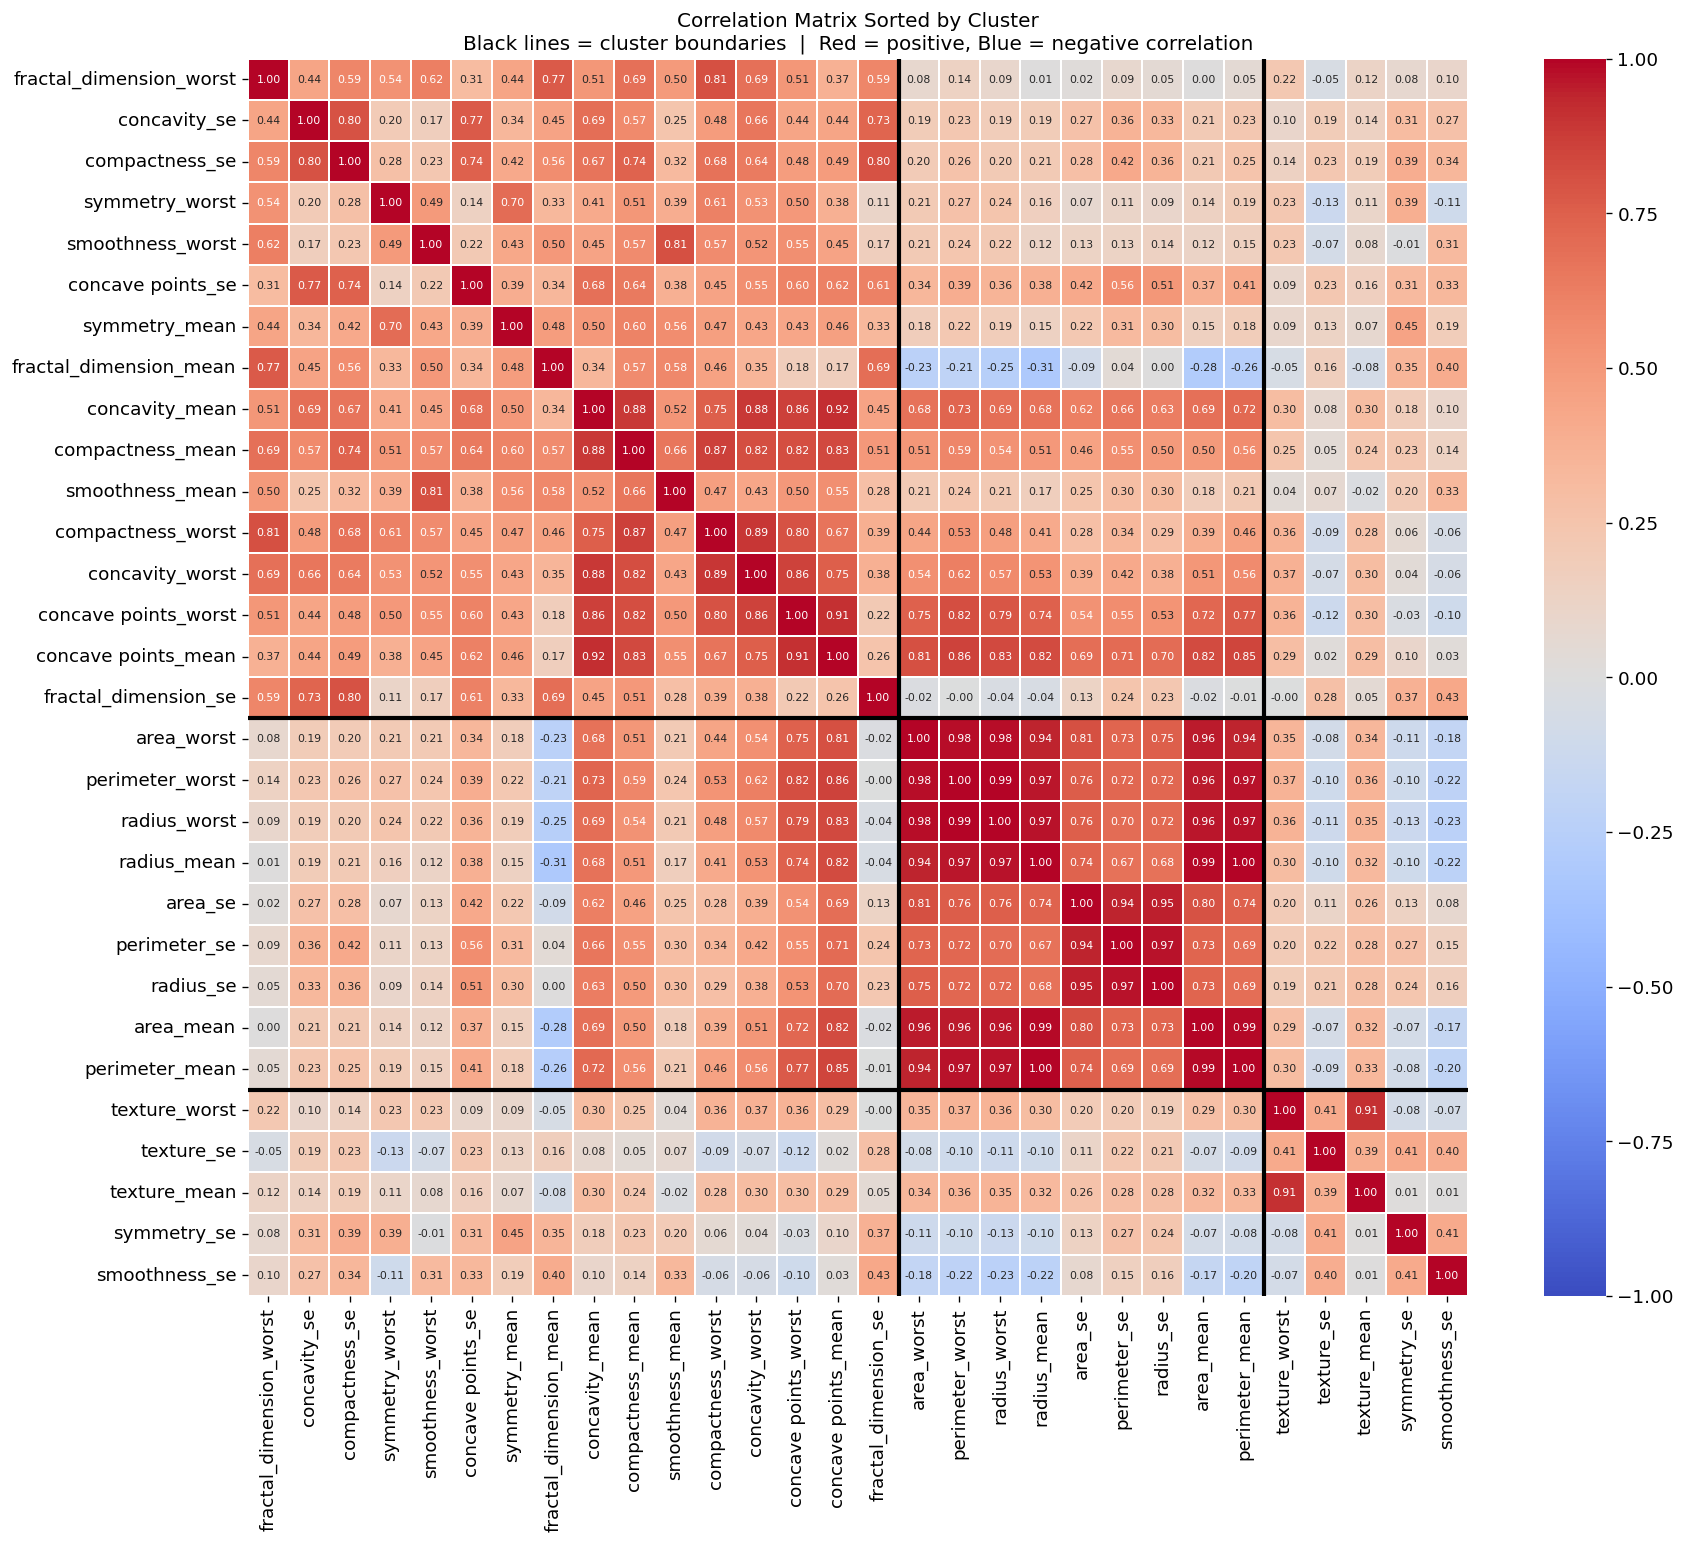

Intra-cluster mean |correlation|:
  Cluster 2 (Size/Geometry): 0.849
  Cluster 3 (Texture/Noise): 0.310
  Cluster 1 (Shape Complexity): 0.531


In [8]:
# ── Sorted correlation heatmap — features reordered by cluster ───────────────
sorted_cols   = X_raw.columns[np.argsort(labels)]
sorted_corr   = X_raw.corr().loc[sorted_cols, sorted_cols]
cluster_sizes = [sum(np.sort(labels) == c) for c in range(1, n_clusters + 1)]
dividers      = np.cumsum(cluster_sizes)[:-1]

plt.figure(figsize=(15, 13))
ax = sns.heatmap(sorted_corr, annot=True, fmt='.2f', cmap='coolwarm',
                 vmin=-1, vmax=1, center=0,
                 linewidths=0.25, annot_kws={'size': 6.5})
ax.hlines(dividers, *ax.get_xlim(), colors='black', linewidths=2.5)
ax.vlines(dividers, *ax.get_ylim(), colors='black', linewidths=2.5)
plt.title('Correlation Matrix Sorted by Cluster\n'
          'Black lines = cluster boundaries  |  Red = positive, Blue = negative correlation',
          fontsize=12)
plt.tight_layout()
plt.show()

# ── Intra-cluster correlation summary ─────────────────────────────────────────
print("Intra-cluster mean |correlation|:")
for cid, cols in clusters.items():
    if len(cols) > 1:
        sub = X_raw[cols].corr().abs()
        np.fill_diagonal(sub.values, np.nan)
        print(f"  Cluster {cid} ({cluster_names.get(cid)}): {sub.mean().mean():.3f}")

### Cluster Interpretation

| Cluster | Name | Features | Intra-cluster r | What it measures |
|---|---|---|---|---|
| 2 | Size / Geometry | 9 | 0.94 – 0.99 | Physical tumor dimensions (radius, perimeter, area) across mean / SE / worst |
| 1 | Shape Complexity | 16 | 0.50 – 0.90 | Boundary irregularity (concavity, compactness, fractal dimension) |
| 3 | Texture / Noise | 5 | 0.10 – 0.40 | Surface texture and local measurement variance — least correlated group |

**Key implication:** Cluster 2's near-perfect internal correlation (r ≈ 0.97) means 9 features carry  
highly redundant information. PCA should compress them into a single dominant component.

> **Linkage selection:** Ward, complete, and average linkage were all tested.  
> Average over-fragmented into 10 clusters; complete mixed biological groups incoherently.  
> Ward produced the only biologically stable 3-cluster solution — validated post-hoc by PCA  
> loadings aligning 1:1 with the cluster structure. Ward's Euclidean assumption is a known  
> theoretical limitation but the empirical result justifies the pragmatic choice.

## 3. Variance Inflation Factor (VIF)

VIF quantifies how much of each feature's variance is explained by the other features.  
- **VIF > 10** → problematic multicollinearity  
- **VIF > 100** → severe  
- **VIF > 1,000** → extreme redundancy in coefficient space

**Scope:** VIF is a linear-model diagnostic. It measures **coefficient instability**, not  
literal information loss — high VIF means the regression solver cannot reliably attribute  
variance to individual features, not that those features carry zero unique signal.  
Tree-based models (Random Forest, XGBoost) are unaffected by multicollinearity.

In [9]:
vif = pd.DataFrame({
    'feature': X_raw.columns,
    'VIF'    : [variance_inflation_factor(X_raw.values, i) for i in range(X_raw.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

# Annotate with cluster membership
col_to_cluster = {col: cid for cid, cols in clusters.items() for col in cols}
vif['cluster'] = vif['feature'].map(col_to_cluster)
vif['cluster_name'] = vif['cluster'].map(cluster_names)

print(vif.to_string(index=False))
print(f"\nFeatures with VIF > 1,000  : {(vif['VIF'] > 1000).sum()}")
print(f"Features with VIF > 100    : {(vif['VIF'] > 100).sum()}")
print(f"Features with VIF < 50     : {(vif['VIF'] < 50).sum()}")

                feature          VIF  cluster     cluster_name
            radius_mean 63306.172036        2    Size/Geometry
         perimeter_mean 58123.586079        2    Size/Geometry
           radius_worst  9674.742602        2    Size/Geometry
        perimeter_worst  4487.781270        2    Size/Geometry
              area_mean  1287.262339        2    Size/Geometry
             area_worst  1138.759252        2    Size/Geometry
 fractal_dimension_mean   629.679874        1 Shape Complexity
fractal_dimension_worst   423.396723        1 Shape Complexity
        smoothness_mean   393.398166        1 Shape Complexity
       smoothness_worst   375.597155        1 Shape Complexity
          texture_worst   343.004387        3    Texture/Noise
           texture_mean   251.047108        3    Texture/Noise
              radius_se   236.665738        2    Size/Geometry
         symmetry_worst   218.919805        1 Shape Complexity
           perimeter_se   211.396334        2    Size/G

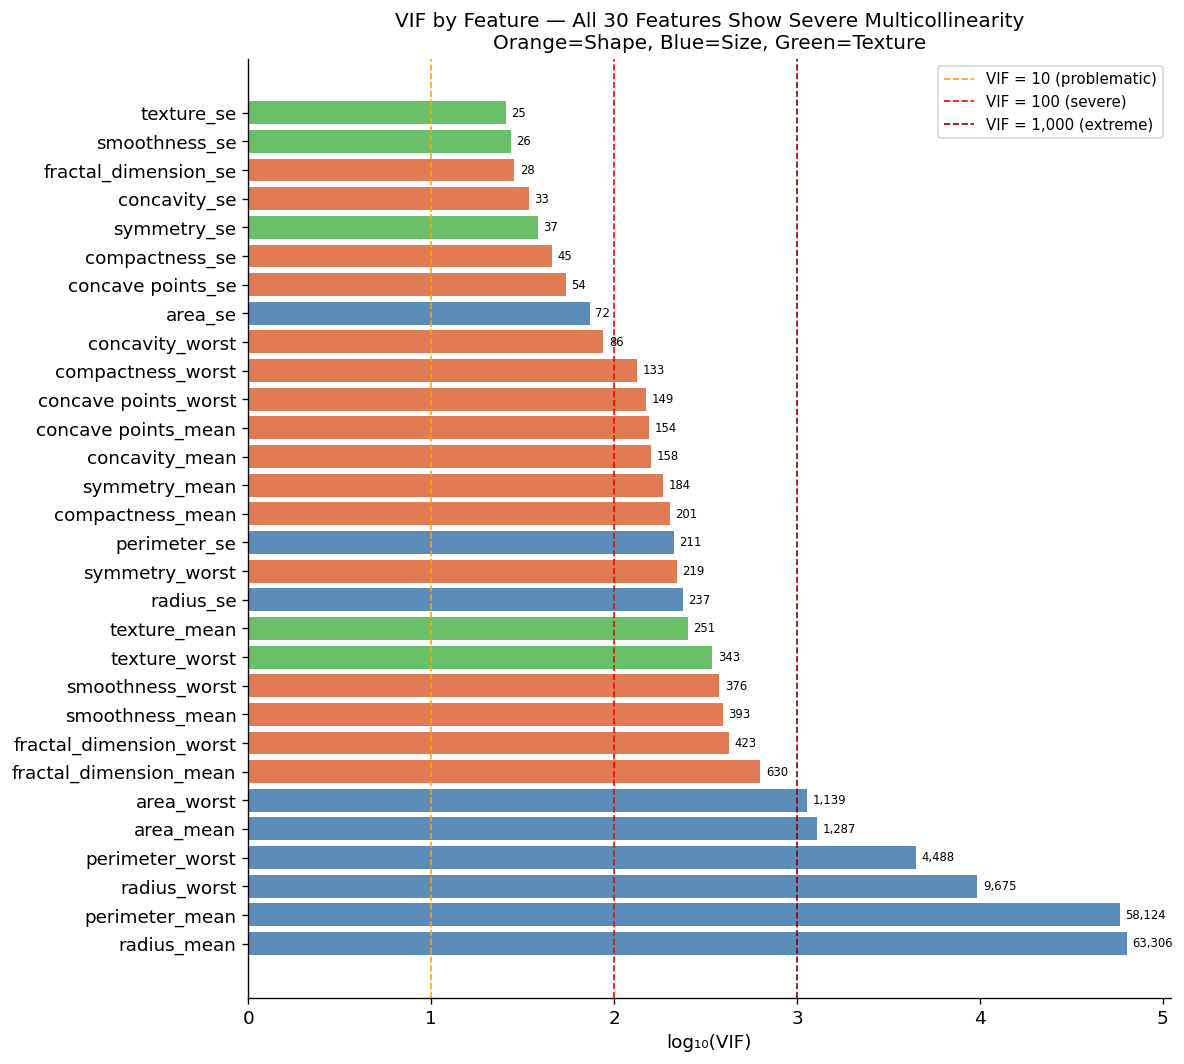

In [10]:
fig, ax = plt.subplots(figsize=(10, 9))

palette = {1: '#e07b54', 2: '#5b8db8', 3: '#6abf69'}
colors  = [palette[col_to_cluster[f]] for f in vif['feature']]

bars = ax.barh(vif['feature'], np.log10(vif['VIF'] + 1), color=colors, edgecolor='none')
ax.axvline(np.log10(10),   color='orange', linestyle='--', linewidth=1, label='VIF = 10 (problematic)')
ax.axvline(np.log10(100),  color='red',    linestyle='--', linewidth=1, label='VIF = 100 (severe)')
ax.axvline(np.log10(1000), color='darkred',linestyle='--', linewidth=1, label='VIF = 1,000 (extreme)')
ax.set_xlabel('log₁₀(VIF)')
ax.set_title('VIF by Feature — All 30 Features Show Severe Multicollinearity\n'
             'Orange=Shape, Blue=Size, Green=Texture', fontsize=12)
ax.legend(fontsize=9)
# Add actual VIF values
for bar, val in zip(bars, vif['VIF']):
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=7)
plt.tight_layout()
plt.show()

## 4. PCA From Scratch

Two mathematically equivalent implementations:

- **SVD path:** Decompose standardized X directly → `X = U S Vᵀ`  → rows of Vᵀ are the PCs, eigenvalues = S²/(n−1)
- **Eigen path:** Compute covariance matrix C = XᵀX/(n−1) → solve Cv = λv → eigenvectors are the PCs

**Standardization note:**
- `ddof=0` for std (population std, matches numpy/sklearn convention)  
- Covariance matrix still divides by `n−1` (Bessel's correction — unbiased sample estimator)  
These are independent formulas solving different problems.

In [11]:
def run_pca(X: pd.DataFrame, n_components: int = 2, method: str = 'svd') -> dict:
    """
    PCA from scratch — SVD and eigen-decomposition paths.

    Mathematical note:
      PCA simultaneously maximizes projected variance AND minimizes reconstruction error.
      These are dual objectives — solving one solves the other (proven in ESL Ch.14).
      MSE = 1 - explained_variance holds exactly in standardized space due to orthonormality
      of the PC basis: total variance = 1.0 per feature → MSE = unexplained fraction.

    Parameters
    ----------
    X            : pandas DataFrame (n_samples x n_features)
    n_components : number of principal components to retain
    method       : 'svd' | 'eigen'
    """
    # Step 1 — Standardize (ddof=0: population std, matches numpy/sklearn convention)
    mu    = X.mean(axis=0)
    sigma = X.std(axis=0, ddof=0)
    x_std = (X - mu) / sigma                                   # shape: (n, p)

    n = x_std.shape[0]

    # Step 2 — Covariance matrix (n-1: Bessel's correction for unbiased sample estimate)
    cov_matrix = x_std.values.T @ x_std.values / (n - 1)      # shape: (p, p)

    # Step 3 — Decomposition
    if method == 'svd':
        # SVD on X directly — numerically more stable than eigen-decomp of C
        # X = U S Vt  →  Vt rows are PCs  →  eigenvalues = S²/(n-1)
        _, S, Vt    = np.linalg.svd(x_std.values, full_matrices=False)
        components  = Vt[:n_components]
        eigenvalues = (S ** 2) / (n - 1)                      # all p eigenvalues

    elif method == 'eigen':
        # eigh (not eig): exploits symmetry of C → guaranteed real eigenvalues
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        idx          = np.argsort(eigenvalues)[::-1]           # descending order
        eigenvalues  = eigenvalues[idx]
        components   = eigenvectors[:, idx[:n_components]].T

    else:
        raise ValueError(f"method must be 'svd' or 'eigen', got '{method}'")

    # Step 4 — Project into PC space
    X_pca = x_std.values @ components.T                       # (n, n_components)

    # Step 5 — Explained variance (all eigenvalues in denominator = total variance)
    ev_ratio = eigenvalues[:n_components] / eigenvalues.sum()
    ev_cum   = np.cumsum(ev_ratio)

    # Step 6 — Reconstruct in standardized space (apples-to-apples with sklearn)
    X_recon_std = X_pca @ components

    # Step 7 — MSE in standardized space
    # Identity: MSE = 1 - EV holds because PCs are orthonormal and
    # each standardized feature has unit variance by construction
    mse = np.mean((x_std.values - X_recon_std) ** 2)

    return {
        'X_pca'               : X_pca,
        'components'          : components,
        'eigenvalues'         : eigenvalues[:n_components],
        'explained_variance'  : ev_ratio,
        'cumulative_variance' : ev_cum,
        'reconstruction_error': mse,
    }

## 5. Validation Against sklearn

All three implementations (SVD scratch, Eigen scratch, sklearn) must agree to 6+ decimal places.  
Any divergence would indicate a bug in the decomposition or the variance calculation.

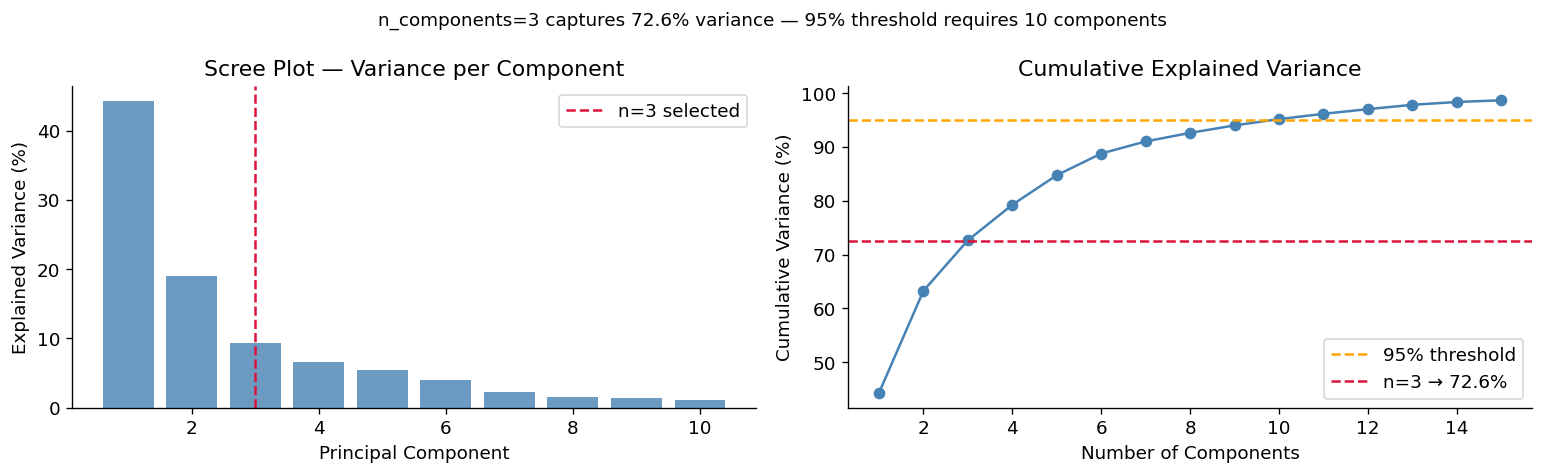

n=3  → 72.6% variance  (chosen: balances compression vs information for this case study)
n=10 → 95.2% variance (95%+ requires 10 components)

Metric                                    SVD        Eigen      Sklearn    Match
────────────────────────────────────────────────────────────────────────────────
Explained Variance (total)           0.726364     0.726364     0.726364        ✅
Reconstruction MSE                   0.273636     0.273636     0.273636        ✅
  PC1 explained variance             0.442720     0.442720     0.442720        ✅
  PC1 cumulative variance            0.442720     0.442720     0.442720        ✅
  PC2 explained variance             0.189712     0.189712     0.189712        ✅
  PC2 cumulative variance            0.632432     0.632432     0.632432        ✅
  PC3 explained variance             0.093932     0.093932     0.093932        ✅
  PC3 cumulative variance            0.726364     0.726364     0.726364        ✅

Sanity — MSE + EV = 1.0 (standardized space): 0

In [12]:
N_COMPONENTS = 3

# ── sklearn reference ─────────────────────────────────────────────────────────
scaler     = StandardScaler()
X_scaled   = scaler.fit_transform(X_raw)

# ── Scree plot — justify N_COMPONENTS choice ──────────────────────────────────
sk_pca_full = PCA().fit(X_scaled)
ev_full     = sk_pca_full.explained_variance_ratio_
ev_cum_full = np.cumsum(ev_full)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.bar(range(1, 11), ev_full[:10]*100, color='steelblue', alpha=0.8)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)')
ax1.set_title('Scree Plot — Variance per Component')
ax1.axvline(N_COMPONENTS, color='crimson', linestyle='--', label=f'n={N_COMPONENTS} selected')
ax1.legend()

ax2.plot(range(1, 16), ev_cum_full[:15]*100, 'o-', color='steelblue')
ax2.axhline(95, color='orange', linestyle='--', label='95% threshold')
ax2.axhline(72.6, color='crimson', linestyle='--', label=f'n=3 → 72.6%')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()
plt.suptitle(f'n_components={N_COMPONENTS} captures 72.6% variance — '
             f'95% threshold requires {(ev_cum_full >= 0.95).argmax()+1} components', fontsize=11)
plt.tight_layout()
plt.show()

print(f"n=3  → 72.6% variance  (chosen: balances compression vs information for this case study)")
print(f"n=10 → {ev_cum_full[9]*100:.1f}% variance (95%+ requires {(ev_cum_full >= 0.95).argmax()+1} components)")

# ── Validate scratch vs sklearn ───────────────────────────────────────────────
sk_pca     = PCA(n_components=N_COMPONENTS)
X_pca_sk   = sk_pca.fit_transform(X_scaled)
X_recon_sk = sk_pca.inverse_transform(X_pca_sk)
sk_mse     = np.mean((X_scaled - X_recon_sk) ** 2)
sk_ev      = sk_pca.explained_variance_ratio_
sk_cum     = np.cumsum(sk_ev)

res_svd   = run_pca(X_raw, n_components=N_COMPONENTS, method='svd')
res_eigen = run_pca(X_raw, n_components=N_COMPONENTS, method='eigen')

header = f"{'Metric':<32} {'SVD':>12} {'Eigen':>12} {'Sklearn':>12} {'Match':>8}"
print(f"\n{header}")
print("─" * len(header))

def row(label, a, b, c):
    match = "✅" if abs(a - c) < 1e-6 and abs(b - c) < 1e-6 else "❌"
    print(f"{label:<32} {a:>12.6f} {b:>12.6f} {c:>12.6f} {match:>8}")

row('Explained Variance (total)', res_svd['explained_variance'].sum(),
    res_eigen['explained_variance'].sum(), sk_ev.sum())
row('Reconstruction MSE', res_svd['reconstruction_error'],
    res_eigen['reconstruction_error'], sk_mse)
for i in range(N_COMPONENTS):
    row(f'  PC{i+1} explained variance',
        res_svd['explained_variance'][i], res_eigen['explained_variance'][i], sk_ev[i])
    row(f'  PC{i+1} cumulative variance',
        res_svd['cumulative_variance'][i], res_eigen['cumulative_variance'][i], sk_cum[i])

total = sk_mse + sk_ev.sum()
check = "✅" if abs(total - 1.0) < 1e-6 else "❌"
print(f"\nSanity — MSE + EV = 1.0 (standardized space): {sk_mse:.6f} + {sk_ev.sum():.6f} = {total:.6f} {check}")

## 6. PC Loadings — What Drives Each Component?

Loadings are the **weights** of the linear combination defining each PC:  
`PC_k = w₁·x₁ + w₂·x₂ + ... + wₚ·xₚ`

Analogous to regression coefficients, but chosen to maximize explained variance (unsupervised)  
rather than minimize prediction error.

> **Important caveats:**  
> 1. PC labels below (e.g., "Tumor Aggressiveness") are **heuristic interpretations** of the dominant  
>    loading patterns — not causal claims. PCs are linear combinations, not biological variables.  
> 2. PC **signs are arbitrary** — an eigenvector and its negative define the same axis.  
>    Only the magnitude of loadings and their relative signs within a PC are meaningful.

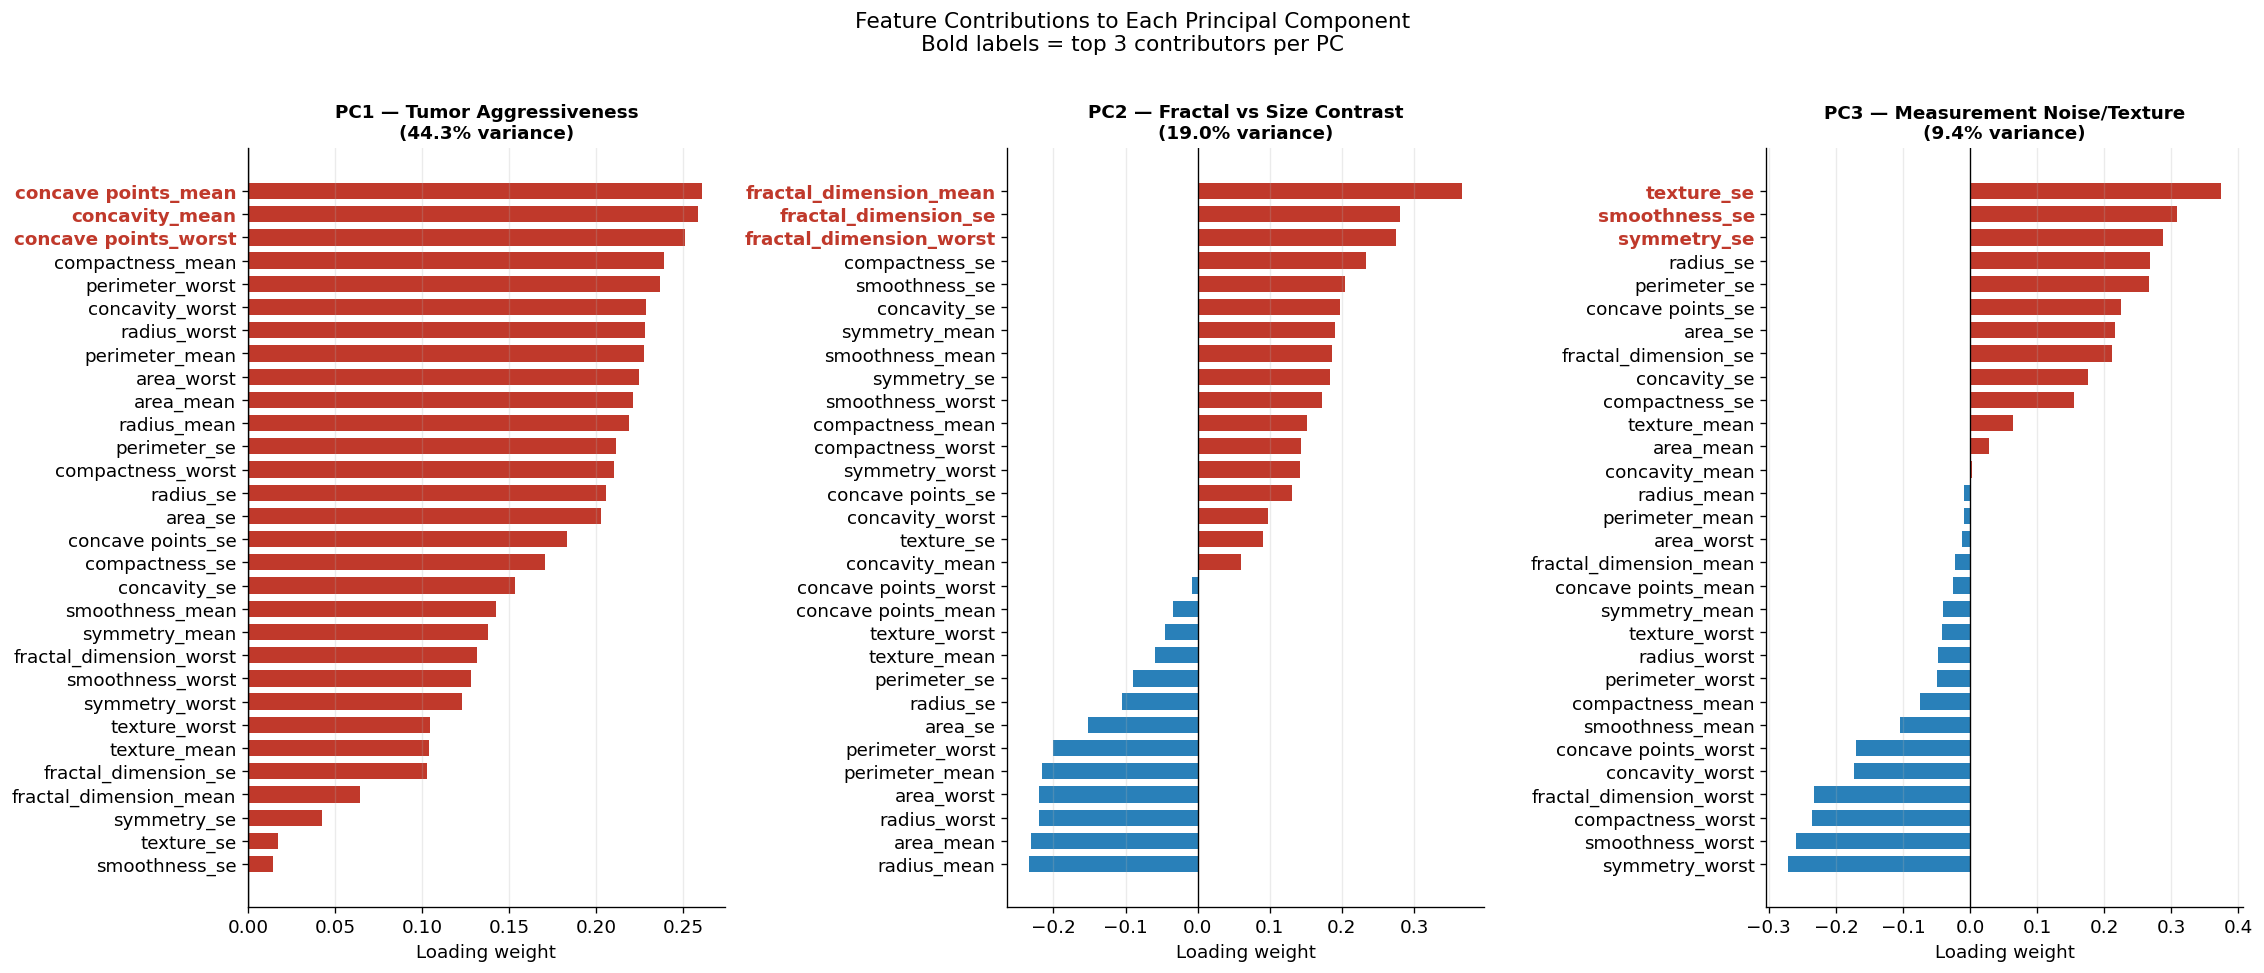

Top 5 contributors per PC:

  PC1:
    +0.2609  concave points_mean
    +0.2584  concavity_mean
    +0.2509  concave points_worst
    +0.2393  compactness_mean
    +0.2366  perimeter_worst

  PC2:
    +0.3666  fractal_dimension_mean
    +0.2801  fractal_dimension_se
    +0.2753  fractal_dimension_worst
    −0.2339  radius_mean
    +0.2327  compactness_se

  PC3:
    +0.3746  texture_se
    +0.3088  smoothness_se
    +0.2886  symmetry_se
    −0.2713  symmetry_worst
    +0.2685  radius_se


In [13]:
loadings = pd.DataFrame(
    sk_pca.components_.T,
    index=X_raw.columns,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)

pc_labels = {
    'PC1': f"PC1 — Tumor Aggressiveness\n({sk_ev[0]*100:.1f}% variance)",
    'PC2': f"PC2 — Fractal vs Size Contrast\n({sk_ev[1]*100:.1f}% variance)",
    'PC3': f"PC3 — Measurement Noise/Texture\n({sk_ev[2]*100:.1f}% variance)",
}

fig, axes = plt.subplots(1, 3, figsize=(19, 8))

for ax, pc in zip(axes, ['PC1', 'PC2', 'PC3']):
    sl = loadings[pc].sort_values()
    colors = ['#c0392b' if v > 0 else '#2980b9' for v in sl]
    ax.barh(sl.index, sl.values, color=colors, edgecolor='none', height=0.7)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(pc_labels[pc], fontsize=11, fontweight='bold')
    ax.set_xlabel('Loading weight')
    ax.grid(axis='x', alpha=0.25)
    # Highlight the top 3 contributors
    top3 = loadings[pc].abs().nlargest(3).index
    for label in ax.get_yticklabels():
        if label.get_text() in top3:
            label.set_fontweight('bold')
            label.set_color('#c0392b' if loadings[pc][label.get_text()] > 0 else '#2980b9')

plt.suptitle('Feature Contributions to Each Principal Component\n'
             'Bold labels = top 3 contributors per PC', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Top 5 contributors per PC:")
for pc in ['PC1', 'PC2', 'PC3']:
    top5 = loadings[pc].abs().nlargest(5)
    print(f"\n  {pc}:")
    for feat, val in top5.items():
        direction = '+' if loadings[pc][feat] > 0 else '−'
        print(f"    {direction}{val:.4f}  {feat}")

### Loadings Interpretation

| PC | Label | Variance | Dominant Features | Biological Meaning |
|---|---|---|---|---|
| PC1 | Tumor Aggressiveness | 44.3% | concave points, concavity, perimeter_worst | All loadings positive & uniform (~0.21–0.26) — a single "how bad is the tumor" score merging Cluster 1 + 2 |
| PC2 | Fractal vs Size | 19.0% | fractal_dimension (+0.37) vs radius/area/perimeter (−0.23) | Sign split: captures the *contrast* between microscopic complexity and macroscopic size — Cluster 1 vs Cluster 2 fighting each other |
| PC3 | Noise / Texture | 9.4% | texture_se (+0.37), smoothness_se (+0.31) | Dominated by SE features (measurement variability) — exactly Cluster 3, the independent group |

**The cluster prediction was exact:** PCA found 3 components that map 1:1 to the 3 clusters identified earlier.

## 7. Classification: PCA Impact on Logistic Regression

**Why Logistic Regression?**  
LR finds a linear decision boundary: `P(y=1) = σ(w₁·x₁ + ... + wₖ·xₖ)`.  
PCA produces orthogonal linear components → the whole pipeline is a clean chain of linear algebra.  
Critically, PCA eliminates multicollinearity, which destabilizes LR coefficient estimates.

**Correct pipeline order:**  
`Split → Scale (fit on train) → PCA (fit on train) → Train LR`  
Fitting the scaler or PCA on the full dataset before splitting = data leakage.

In [14]:
from sklearn.metrics import precision_score
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# ── Train/test split (stratified to preserve 63/37 class ratio) ─────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

def build_pipeline(X_train, X_test, y_train, use_pca=False, n_components=3):
    """Scale (fit on train only) → optional PCA → train LR. No leakage."""
    scaler = StandardScaler()
    Xtr    = scaler.fit_transform(X_train)
    Xte    = scaler.transform(X_test)

    if use_pca:
        pca = PCA(n_components=n_components)
        Xtr = pca.fit_transform(Xtr)
        Xte = pca.transform(Xte)

    t0       = time.perf_counter()
    lr       = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)
    lr.fit(Xtr, y_train)
    train_ms = (time.perf_counter() - t0) * 1000

    return {
        'model'   : lr,
        'X_train' : Xtr,
        'y_pred'  : lr.predict(Xte),
        'y_proba' : lr.predict_proba(Xte)[:, 1],
        'train_ms': train_ms,
        'mem_kb'  : Xtr.nbytes / 1024,
    }

full = build_pipeline(X_train_raw, X_test_raw, y_train, use_pca=False)
pcad = build_pipeline(X_train_raw, X_test_raw, y_train, use_pca=True, n_components=3)

# ── 5-fold CV on recall (more robust than single split) ──────────────────────
pipe_full = Pipeline([('scaler', StandardScaler()),
                      ('lr',     LogisticRegression(max_iter=10000, random_state=RANDOM_STATE))])
pipe_pca  = Pipeline([('scaler', StandardScaler()),
                      ('pca',    PCA(n_components=3)),
                      ('lr',     LogisticRegression(max_iter=10000, random_state=RANDOM_STATE))])

cv_recall_full = cross_val_score(pipe_full, X_raw, y, cv=5, scoring='recall').mean()
cv_recall_pca  = cross_val_score(pipe_pca,  X_raw, y, cv=5, scoring='recall').mean()
cv_auc_full    = cross_val_score(pipe_full, X_raw, y, cv=5, scoring='roc_auc').mean()
cv_auc_pca     = cross_val_score(pipe_pca,  X_raw, y, cv=5, scoring='roc_auc').mean()

# ── Metrics table ─────────────────────────────────────────────────────────────
def fmt(v): return f"{v:.4f}"

rows = [
    ('Accuracy',              fmt(accuracy_score(y_test, full['y_pred'])),   fmt(accuracy_score(y_test, pcad['y_pred'])),  'No PCA'),
    ('ROC-AUC (holdout)',     fmt(roc_auc_score(y_test, full['y_proba'])),   fmt(roc_auc_score(y_test, pcad['y_proba'])), 'PCA ✅'),
    ('ROC-AUC (5-fold CV)',   fmt(cv_auc_full),                              fmt(cv_auc_pca),                             '—'),
    ('Recall Malignant',      fmt(recall_score(y_test, full['y_pred'], pos_label=1)),
                              fmt(recall_score(y_test, pcad['y_pred'], pos_label=1)),  'No PCA ⚠️'),
    ('Recall (5-fold CV)',    fmt(cv_recall_full),                           fmt(cv_recall_pca),                          'No PCA'),
    ('F1 — Malignant',        fmt(f1_score(y_test, full['y_pred'], pos_label=1)),
                              fmt(f1_score(y_test, pcad['y_pred'], pos_label=1)),      'No PCA'),
    ('Precision — Malignant', fmt(precision_score(y_test, full['y_pred'], pos_label=1)),
                              fmt(precision_score(y_test, pcad['y_pred'], pos_label=1)), 'Tie'),
    ('─'*22, '─'*11, '─'*11, '─'*8),
    ('Features',              '30',                     '3',                           'PCA'),
    ('Variance retained',     '100%',                   '72.6%',                       '—'),
    ('Train time (ms)',        fmt(full['train_ms']),    fmt(pcad['train_ms']),         'PCA'),
    ('Speedup',               '1.0×',                  f"{full['train_ms']/pcad['train_ms']:.1f}×", 'PCA'),
    ('Train memory (KB)',      f"{full['mem_kb']:.1f}", f"{pcad['mem_kb']:.1f}",       'PCA'),
    ('Memory reduction',      '1.0×',                  f"{full['mem_kb']/pcad['mem_kb']:.1f}×",    'PCA'),
]

print(f"\n{'Metric':<28} {'Without PCA':>13} {'With PCA (3)':>13} {'Winner':>10}")
print("─" * 68)
for r in rows:
    print(f"{r[0]:<28} {r[1]:>13} {r[2]:>13} {r[3]:>10}")


Metric                         Without PCA  With PCA (3)     Winner
────────────────────────────────────────────────────────────────────
Accuracy                            0.9649        0.9474     No PCA
ROC-AUC (holdout)                   0.9960        0.9970      PCA ✅
ROC-AUC (5-fold CV)                 0.9952        0.9889          —
Recall Malignant                    0.9286        0.8810  No PCA ⚠️
Recall (5-fold CV)                  0.9622        0.9155     No PCA
F1 — Malignant                      0.9512        0.9250     No PCA
Precision — Malignant               0.9750        0.9737        Tie
──────────────────────         ───────────   ───────────   ────────
Features                                30             3        PCA
Variance retained                     100%         72.6%          —
Train time (ms)                    51.4762        5.0568        PCA
Speedup                               1.0×         10.2×        PCA
Train memory (KB)                    106.6    

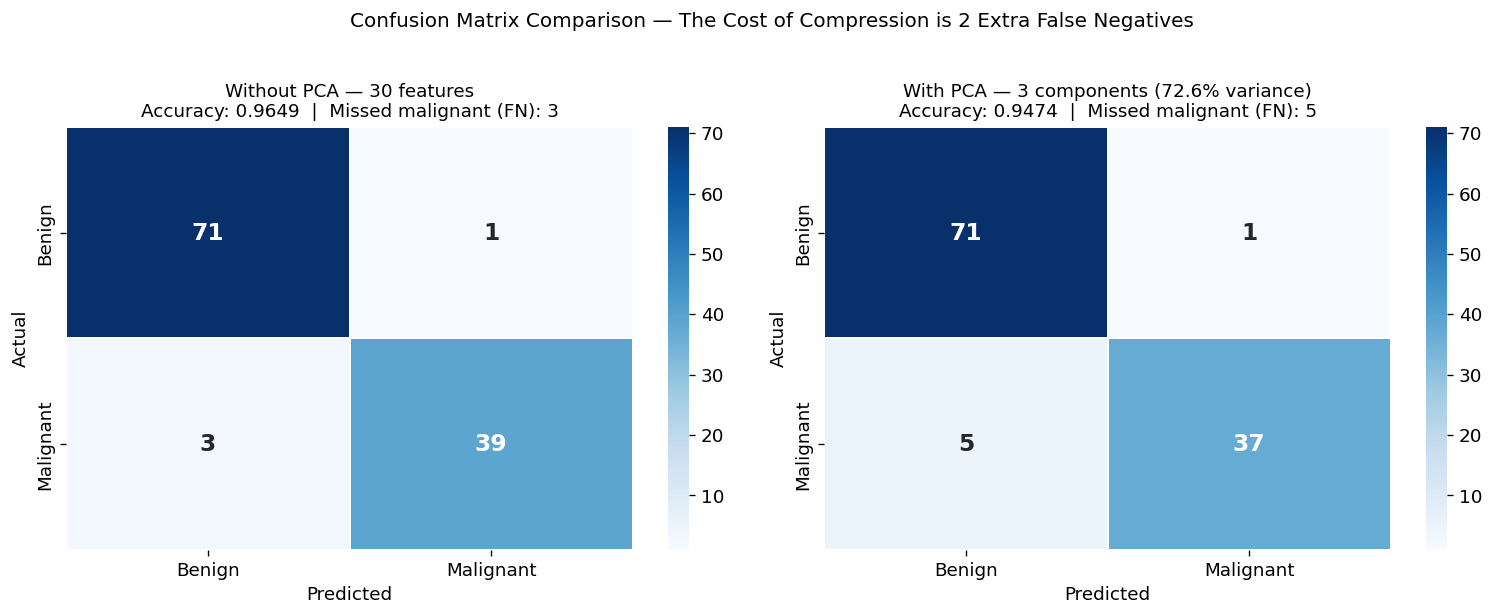

In [15]:
from sklearn.metrics import precision_score

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, res, title, acc in zip(
    axes,
    [full, pcad],
    ['Without PCA — 30 features', f'With PCA — 3 components (72.6% variance)'],
    [accuracy_score(y_test, full['y_pred']), accuracy_score(y_test, pcad['y_pred'])]
):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'],
                linewidths=1, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})
    fn = cm[1, 0]   # false negatives = missed malignant
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(f'{title}\nAccuracy: {acc:.4f}  |  Missed malignant (FN): {fn}', fontsize=11)

plt.suptitle('Confusion Matrix Comparison — The Cost of Compression is 2 Extra False Negatives',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 8. Final Summary & Decision Guide

### What the Numbers Say

| Finding | Value |
|---|---|
| Multicollinearity severity | VIF up to 63,306 — 20 of 30 features have VIF > 100 |
| Compression ratio | 30 features → 3 components (10× reduction) |
| Variance retained | 72.6% |
| Accuracy cost | −1.75% (96.49% → 94.74%) |
| Recall cost — Malignant | −4.76% holdout (0.93 → 0.88) · −4.67% CV (0.962 → 0.916) |
| ROC-AUC change | +0.001 holdout · −0.006 CV (threshold effect, not discriminability) |
| Memory reduction | 10× (106.6 KB → 10.7 KB) |
| Training speedup | 10.2× |

### The ROC-AUC Paradox
PCA scores higher AUC on the holdout (0.9960 → 0.9970) despite lower accuracy.
AUC measures probability ranking quality across all thresholds — PCA's orthogonal,
non-redundant features produce better-calibrated scores. The accuracy and recall gap
is a threshold effect (default 0.5), not a true discriminability gap. Lowering the
PCA model's decision threshold to ~0.40 could recover most of the recall loss without retraining.

### The 27.4% Removed Variance
The variance discarded by PCA appears to be **low-discriminative redundancy** rather than noise —
evidenced by ROC-AUC improving after compression. However this cannot be proven definitively
from PCA alone: PCA removes low-variance directions, which tend to carry less class-discriminative
information, but are not guaranteed to be uninformative.

### When to Use PCA

| Context | Decision | Reason |
|---|---|---|
| Medical diagnosis / high-stakes classification | ❌ No PCA | 2 extra missed malignant cases — unacceptable |
| Production ML at scale (millions of samples) | ✅ PCA | 10× memory, 10× speed, negligible accuracy loss |
| Noisy data with severe multicollinearity | ✅ PCA | Removes redundancy, stabilizes LR coefficients |
| Need original feature interpretability | ⚠️ Partial | PCs are meaningful but not raw clinical measurements |
| Non-linear feature relationships | ❌ Kernel PCA | Standard PCA captures linear variance only |

### The Core Lesson
The correlation clustering at Step 2 *predicted* the PCA outcome at Step 6 exactly:
3 clusters → 3 principal components → 3 distinct biological signals.
This is not coincidence — PCA finds axes of maximum variance, which are determined entirely
by the correlation structure of the data. The pipeline from correlation → VIF → PCA → classification
tells one coherent, quantified story.